In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
data = {
    "Hours_Studied": [1, 2, 3, 4, 5, 6, 7, 8, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 1.5, 2.2, 3.2, 4.2, 5.2, 6.2, 7.2, 8.2, 9, 9.5],
    "Marks": [35, 40, 45, 50, 55, 60, 65, 70, 42, 47, 52, 57, 62, 67, 72, 38, 41, 46, 51, 56, 61, 66, 71, 75, 78]
}

df_regression = pd.DataFrame(data)

df_regression.head()

,Hours_Studied,Marks
0,1.0,35
1,2.0,40
2,3.0,45
3,4.0,50
4,5.0,55


In [3]:
df_regression.to_csv("Student_Marks_Dataset.csv", index=False)

print("Student_Marks_Dataset.csv created successfully.")

Student_Marks_Dataset.csv created successfully.


In [4]:
print("Dataset shape:", df_regression.shape)

print("\nMissing values:")
print(df_regression.isnull().sum())

print("\nDataset information:")
print(df_regression.info())

print("\nStatistical summary:")
print(df_regression.describe())

Dataset shape: (25, 2)

Missing values:
Hours_Studied    0
Marks            0
dtype: int64

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Hours_Studied  25 non-null     float64
 1   Marks          25 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 532.0 bytes
None

Statistical summary:
       Hours_Studied      Marks
count      25.000000  25.000000
mean        5.236000  56.080000
std         2.492803  12.456324
min         1.000000  35.000000
25%         3.200000  46.000000
50%         5.200000  56.000000
75%         7.200000  66.000000
max         9.500000  78.000000


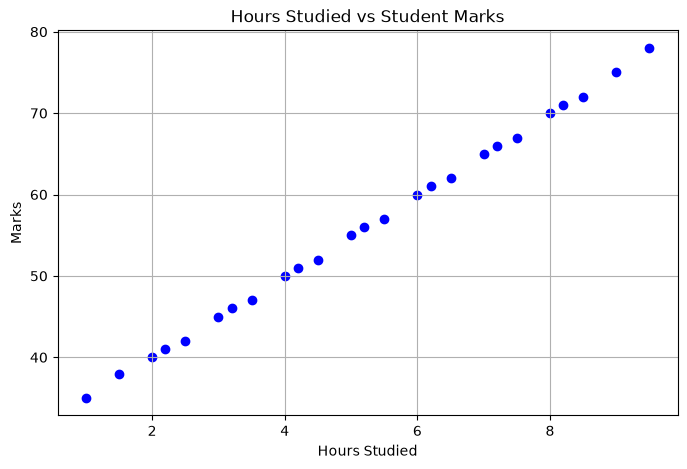

In [5]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_regression["Hours_Studied"],
    df_regression["Marks"],
    color="blue"
)

plt.title("Hours Studied vs Student Marks")
plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.grid(True)
plt.show()

In [6]:
X = df_regression[["Hours_Studied"]]
y = df_regression["Marks"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Hours_Studied
0            1.0
1            2.0
2            3.0
3            4.0
4            5.0

Target:
0    35
1    40
2    45
3    50
4    55
Name: Marks, dtype: int64


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (20, 1)
Testing data size: (5, 1)


In [9]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [10]:
print("Intercept:", linear_model.intercept_)
print("Coefficient:", linear_model.coef_[0])

Intercept: 30.006367712549075
Coefficient: 4.985299419593663


In [11]:
y_pred = linear_model.predict(X_test)

prediction_results = pd.DataFrame({
    "Actual Marks": y_test.values,
    "Predicted Marks": y_pred
})

prediction_results

,Actual Marks,Predicted Marks
0,42,42.469616
1,41,40.974026
2,35,34.991667
3,75,74.874062
4,57,57.425515


In [12]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 0.2110749450315069
MSE: 0.08364127190605233
RMSE: 0.2892080080254562
R² Score: 0.9995994191958523


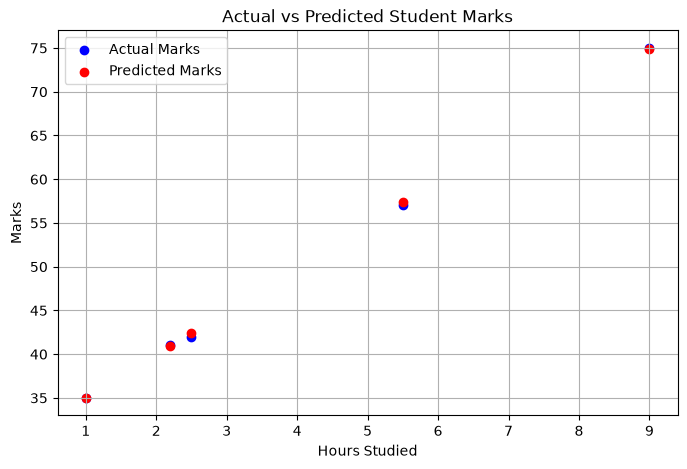

In [13]:
plt.figure(figsize=(8, 5))

plt.scatter(X_test, y_test, color="blue", label="Actual Marks")
plt.scatter(X_test, y_pred, color="red", label="Predicted Marks")

plt.title("Actual vs Predicted Student Marks")
plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.legend()
plt.grid(True)
plt.show()

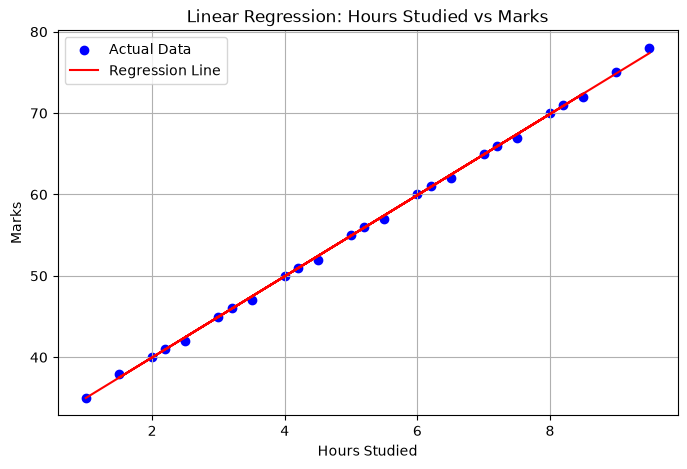

In [14]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_regression["Hours_Studied"],
    df_regression["Marks"],
    color="blue",
    label="Actual Data"
)

plt.plot(
    df_regression["Hours_Studied"],
    linear_model.predict(X),
    color="red",
    label="Regression Line"
)

plt.title("Linear Regression: Hours Studied vs Marks")
plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
print("Conclusion:")
print("A Linear Regression model was used to predict student marks from hours studied.")
print("The model achieved a very high R² score of", r2, "— however, this is expected")
print("because the sample dataset was constructed with a near-perfect linear relationship")
print("between hours studied and marks. Real-world data would likely show more variation,")
print("since factors other than study hours (e.g., prior knowledge, exam difficulty)")
print("also influence marks. This project demonstrates the Linear Regression workflow")
print("rather than a fully realistic prediction scenario.")

Conclusion:
A Linear Regression model was used to predict student marks from hours studied.
The model achieved a very high R² score of 0.9995994191958523 — however, this is expected
because the sample dataset was constructed with a near-perfect linear relationship
between hours studied and marks. Real-world data would likely show more variation,
since factors other than study hours (e.g., prior knowledge, exam difficulty)
also influence marks. This project demonstrates the Linear Regression workflow
rather than a fully realistic prediction scenario.
